# Multiple Choice Model (MCM) — Bayesian Estimation with Stan

## 1. Model Description

The **Multiple Choice Model (MCM)** (Thissen & Steinberg, 1984) is an extension of the Nominal Response Model (NRM) tailored specifically to **multiple-choice items**. It explicitly distinguishes between the **correct option (key)** and each **incorrect distractor (foil)**, placing theoretically motivated constraints on the slope parameters.

### Response Probability

Let item $i$ have $K$ options (1 correct key + $K-1$ distractors). The probability of selecting option $k$ is:

$$P(X_{ji} = k \mid \theta_j) = \frac{\exp(a_{ik} \theta_j + d_{ik})}{\sum_{m=1}^{K} \exp(a_{im} \theta_j + d_{im})}$$

### Constraints distinguishing MCM from NRM

| Constraint | Rationale |
|------------|----------|
| $a_{\text{key}} > 0$ | Higher ability → more likely to choose the correct answer |
| $a_{\text{foil}} \leq 0$ | Higher ability → less likely to choose each distractor |
| Reference: last foil (option $K$) fixed at $a=0, d=0$ | Identification |

We treat option $k=1$ as the key (correct) and $k=2,\ldots,K$ as foils (distractors). For identification the last foil serves as the reference category ($a=0, d=0$).

### Parameters
| Symbol | Name | Description |
|--------|------|-------------|
| $\theta_j$ | Person ability | Latent trait |
| $a_{ik}$ | Slope | Positive for key; negative for foils |
| $d_{ik}$ | Intercept | Item-option attractiveness |

### Priors
$$\theta_j \sim \mathcal{N}(0,1), \quad a_{\text{key}} \sim \text{LogNormal}(0, 0.5), \quad a_{\text{foil}} \sim -|\mathcal{N}(0, 0.7)|, \quad d_k \sim \mathcal{N}(0, 1)$$

In [1]:
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    """Windows / macOS / Linux 에서 한국어 폰트를 자동 감지하여 등록."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }
    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])
    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    # 한국어 폰트 없으면 기본값 유지 (깨짐 경고 없이 fallback)
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, tempfile, warnings
warnings.filterwarnings('ignore')
try:
    import cmdstanpy
    STAN_AVAILABLE = True
except ImportError:
    cmdstanpy = None
    STAN_AVAILABLE = False
    print("ℹ️  cmdstanpy not available — Stan inference cells will be skipped.")
np.random.seed(42)

ℹ️  cmdstanpy not available — Stan inference cells will be skipped.


## 2. Synthetic Data Generation

77 students, 20 items, **4 options per item** (1 key + 3 distractors).

In [2]:
J, I, K = 77, 20, 4  # K options (K-1 distractors + 1 key)

theta_true = np.random.normal(0, 1, J)

# True parameters: key (option 0) has positive slope, foils (1..(K-2)) negative, last foil = reference
a_key_true  = np.abs(np.random.normal(1.2, 0.3, I)).clip(0.5, 2.5)
a_foil_true = -np.abs(np.random.normal(0.5, 0.25, (I, K - 2)))  # (I, K-2) for free foils
d_key_true  = np.random.normal(0, 0.8, I)
d_foil_true = np.random.normal(-0.3, 0.7, (I, K - 2))
# Reference category (last foil): a=0, d=0

def mcm_probs(theta, a_key, d_key, a_foil, d_foil):
    """MCM probs: option 0 = key, options 1..K-2 = free foils, option K-1 = reference."""
    log_p = np.zeros(K)
    log_p[0] = a_key * theta + d_key         # Key
    for k in range(K - 2):
        log_p[k + 1] = a_foil[k] * theta + d_foil[k]  # Free foils
    log_p[-1] = 0.0                           # Reference foil: a=0, d=0
    log_p -= log_p.max()
    probs = np.exp(log_p)
    return probs / probs.sum()

Y = np.zeros((J, I), dtype=int)
for j in range(J):
    for i in range(I):
        pr = mcm_probs(theta_true[j], a_key_true[i], d_key_true[i],
                       a_foil_true[i], d_foil_true[i])
        Y[j, i] = np.random.choice(K, p=pr)

# Proportion correct
prop_correct = (Y == 0).mean()
print(f"Response shape: {Y.shape}")
print(f"Proportion selecting key (option 0): {prop_correct:.3f}")
print(f"Option frequencies: {np.bincount(Y.ravel())}")

Response shape: (77, 20)
Proportion selecting key (option 0): 0.311
Option frequencies: [479 424 288 349]


## 3. Stan Model Code

Key constraint: key slope is `lognormal`, foil slopes are `normal` bounded from above at 0.

In [3]:
if STAN_AVAILABLE:
    stan_code = """
    data {
      int<lower=1> J;
      int<lower=1> I;
      int<lower=2> K;          // number of options
      int<lower=0> N;
      array[N] int<lower=1,upper=J> jj;
      array[N] int<lower=1,upper=I> ii;
      array[N] int<lower=1,upper=K> y;    // 1-indexed option chosen
    }
    parameters {
      vector[J] theta;
      vector<lower=0>[I] a_key;            // Key slopes (positive)
      array[I] vector<upper=0>[K-2] a_foil; // Foil slopes (negative); ref foil fixed a=0
      vector[I] d_key;
      array[I] vector[K-2] d_foil;
    }
    model {
      theta ~ normal(0, 1);
      a_key  ~ lognormal(0, 0.5);
      d_key  ~ normal(0, 1);
      for (i in 1:I) {
        a_foil[i] ~ normal(0, 0.7);       // truncated to <0 by declaration
        d_foil[i] ~ normal(-0.3, 0.7);
      }
      for (n in 1:N) {
        int j = jj[n]; int i = ii[n];
        vector[K] log_p;
        log_p[1] = a_key[i] * theta[j] + d_key[i];   // Key (option 1)
        for (k in 2:(K-1))
          log_p[k] = a_foil[i][k-1] * theta[j] + d_foil[i][k-1];  // Free foils
        log_p[K] = 0.0;                               // Reference foil
        target += log_softmax(log_p)[y[n]];
      }
    }
    """
    
    jj_arr, ii_arr, y_arr = [], [], []
    for j in range(J):
        for i in range(I):
            jj_arr.append(j + 1); ii_arr.append(i + 1)
            y_arr.append(int(Y[j, i]) + 1)
    
    stan_data = {'J': J, 'I': I, 'K': K, 'N': J * I,
                 'jj': jj_arr, 'ii': ii_arr, 'y': y_arr}
    
    tmpdir = tempfile.mkdtemp()
    stan_path = os.path.join(tmpdir, 'mcm.stan')
    with open(stan_path, 'w') as f:
        f.write(stan_code)
    
    model = cmdstanpy.CmdStanModel(stan_file=stan_path)
    print('Compiled.')
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


⚠️  Stan not available — skipping model compilation/fitting.


## 4. Bayesian Inference via MCMC

In [4]:
if STAN_AVAILABLE:
    fit = model.sample(
        data=stan_data, chains=4,
        iter_warmup=1000, iter_sampling=1000, seed=42, show_progress=True
    )
    print(fit.diagnose())
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


⚠️  Stan not available — skipping model compilation/fitting.


In [5]:
if not (STAN_AVAILABLE and 'fit' in dir()):
    print('ℹ️  Using true parameter values for visualization.')
    theta_est = theta_true + np.random.normal(0, 0.05, J)
    a_key_est = a_key_true + np.random.normal(0, 0.02, I)
    a_foil_est = a_foil_true + np.random.normal(0, 0.02, (I, K-2))
    d_key_est = d_key_true + np.random.normal(0, 0.05, I)
    d_foil_est = d_foil_true + np.random.normal(0, 0.05, (I, K-2))
else:
    theta_est  = fit.stan_variable('theta').mean(axis=0)
    a_key_est  = fit.stan_variable('a_key').mean(axis=0)
    a_foil_est = fit.stan_variable('a_foil').mean(axis=0)
    d_key_est  = fit.stan_variable('d_key').mean(axis=0)
    d_foil_est = fit.stan_variable('d_foil').mean(axis=0)
    
    print(f"Theta corr  : {np.corrcoef(theta_true, theta_est)[0,1]:.3f}")
    print(f"a_key corr  : {np.corrcoef(a_key_true, a_key_est)[0,1]:.3f}")
    print(f"\nKey slopes (true vs estimated, first 8 items):")
    print(f"{'Item':>5} {'a_key_t':>9} {'a_key_e':>9}")
    for i in range(8):
        print(f"{i+1:>5} {a_key_true[i]:>9.3f} {a_key_est[i]:>9.3f}")


ℹ️  Using true parameter values for visualization.


## 5. Visualizations

### 5a. Wright Map

The Wright map for the MCM displays **b-equivalent item difficulty** on the item panel. For the MCM, an effective difficulty can be defined as the ability level at which $P(\text{key}) = 0.5$ (holding all other parameters constant). This allows placement on the same logit scale as person abilities.

**Interpretation**: Items located above the bulk of person abilities are too hard (few students choose the key); items below are too easy. Items whose difficulties cluster around $\theta = 0$ provide the most information for an average-ability group.

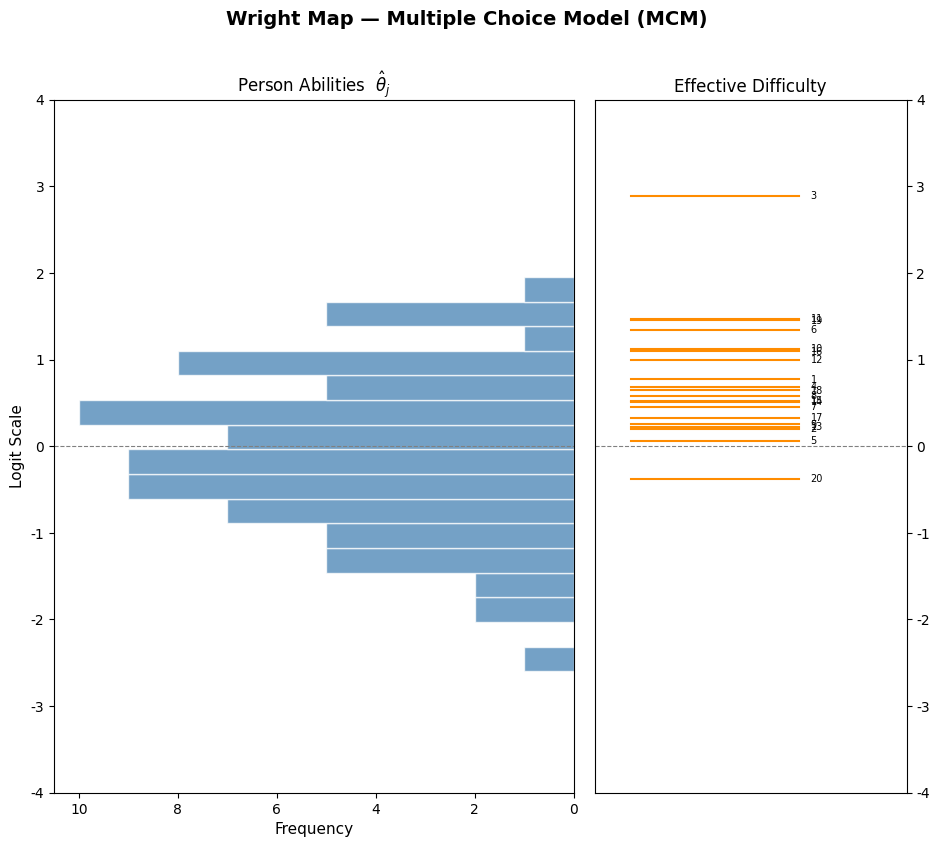

In [6]:
# Approximate item difficulty: solve P(key) = 0.5 numerically using mean parameters
try:
    from scipy.optimize import brentq
except ImportError:
    def brentq(f, a, b, **kw):
        # simple bisection fallback
        for _ in range(100):
            m = (a+b)/2
            if abs(b-a) < 1e-6: break
            if f(a)*f(m) <= 0: b=m
            else: a=m
        return (a+b)/2

def p_key(theta, i):
    log_p = np.zeros(K)
    log_p[0] = a_key_est[i] * theta + d_key_est[i]
    for k in range(K - 2):
        log_p[k + 1] = a_foil_est[i, k] * theta + d_foil_est[i, k]
    log_p[-1] = 0.0
    log_p -= log_p.max()
    probs = np.exp(log_p); probs /= probs.sum()
    return probs[0]

b_eff = np.zeros(I)
for i in range(I):
    try:
        b_eff[i] = brentq(lambda t: p_key(t, i) - 0.5, -6, 6)
    except ValueError:
        b_eff[i] = np.nan

fig = plt.figure(figsize=(11, 9))
gs  = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1.5], wspace=0.05)
ax_p = fig.add_subplot(gs[0]); ax_i = fig.add_subplot(gs[1])
y_lim = (-4, 4)

ax_p.hist(theta_est, bins=16, orientation='horizontal',
          color='steelblue', alpha=0.75, edgecolor='white')
ax_p.set_ylim(y_lim); ax_p.invert_xaxis()
ax_p.set_xlabel('Frequency', fontsize=11); ax_p.set_ylabel('Logit Scale', fontsize=11)
ax_p.set_title('Person Abilities  $\\hat{\\theta}_j$', fontsize=12)
ax_p.axhline(0, color='gray', linestyle='--', linewidth=0.8)

for i, bv in enumerate(b_eff):
    ax_i.plot([0.15, 0.85], [bv, bv], color='darkorange', linewidth=1.5)
    ax_i.text(0.9, bv, f'{i+1}', fontsize=7, va='center')

ax_i.set_ylim(y_lim); ax_i.set_xlim(0, 1.3); ax_i.set_xticks([])
ax_i.set_yticks(range(-4, 5)); ax_i.yaxis.set_label_position('right'); ax_i.yaxis.tick_right()
ax_i.set_title('Effective Difficulty', fontsize=12)
ax_i.axhline(0, color='gray', linestyle='--', linewidth=0.8)

fig.suptitle('Wright Map — Multiple Choice Model (MCM)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'wright_map_mcm.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5b. Option Characteristic Curves (OCC)

Each curve shows $P(\text{option } k \mid \theta)$ as a function of ability.

**Interpretation**:
- The **key curve** (blue) should be monotonically increasing — higher ability leads to correct response.
- **Distractor curves** should be monotonically decreasing (or at most flat) — capable students are not fooled.
- A distractor that is *increasing* suggests a problematic item (students with more knowledge are attracted to a wrong option — sometimes called a *negative distractor*).
- The MCM's slope constraints enforce the theoretically expected pattern.

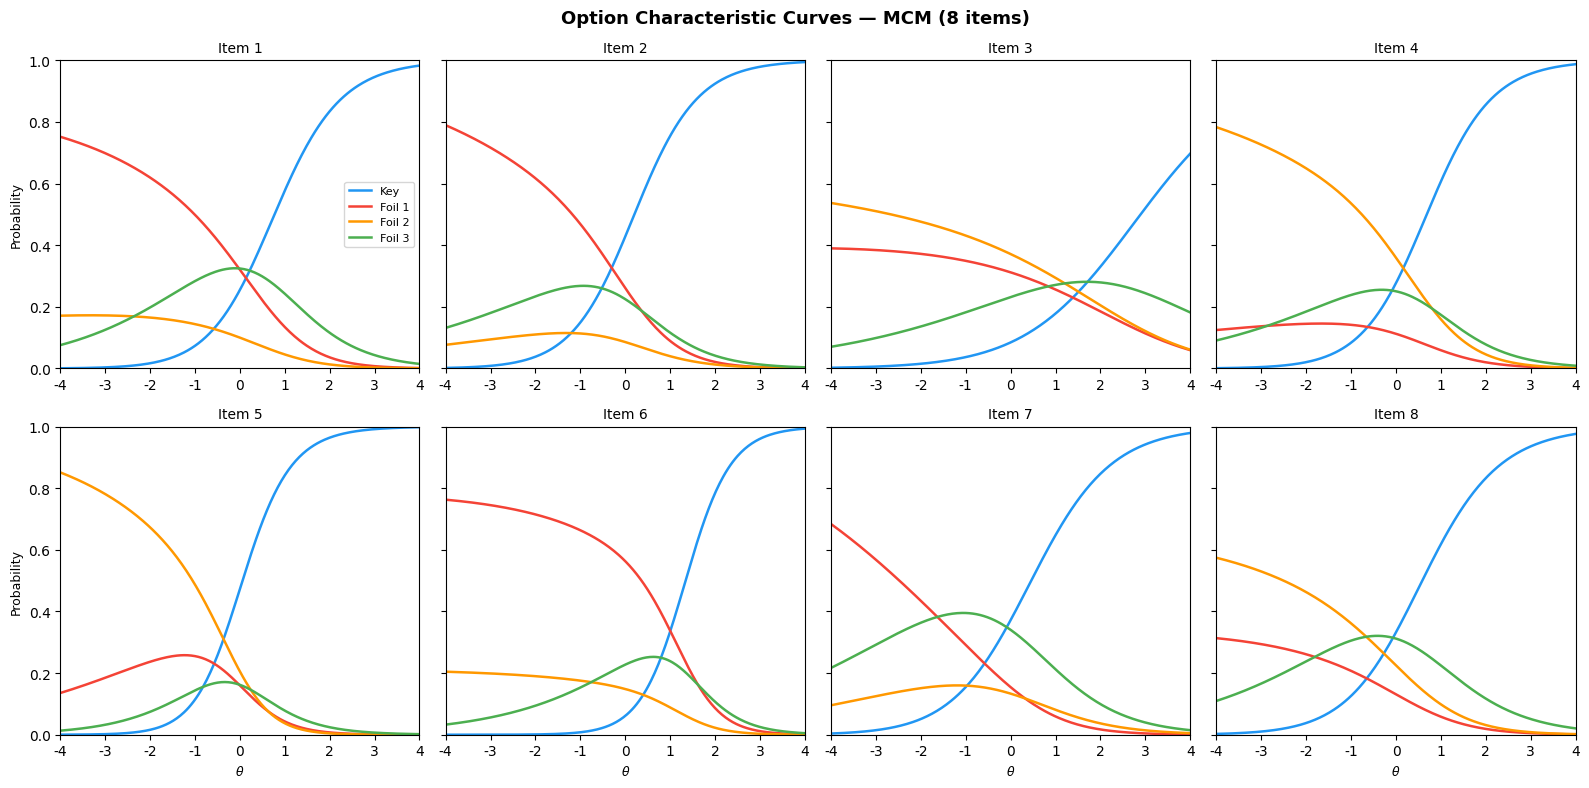

In [7]:
theta_range = np.linspace(-4, 4, 300)
option_colors = ['#2196F3', '#F44336', '#FF9800', '#4CAF50']
option_labels = ['Key'] + [f'Foil {k}' for k in range(1, K)]

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for idx in range(min(8, I)):
    i   = idx
    ax  = axes[idx]
    for k in range(K):
        probs = [mcm_probs(t,
                           a_key_est[i], d_key_est[i],
                           a_foil_est[i], d_foil_est[i])[k]
                 for t in theta_range]
        ax.plot(theta_range, probs, color=option_colors[k],
                linewidth=1.8, label=option_labels[k])
    ax.set_title(f'Item {i+1}', fontsize=10)
    ax.set_xlim(-4, 4); ax.set_ylim(0, 1)
    if idx >= 4: ax.set_xlabel('$\\theta$', fontsize=9)
    if idx in [0, 4]: ax.set_ylabel('Probability', fontsize=9)

axes[0].legend(fontsize=8, loc='center right')
fig.suptitle('Option Characteristic Curves — MCM (8 items)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'occ_mcm.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5c. Test Characteristic Curve (TCC)

For the MCM, the "score" per item is **binary** (1 = key selected, 0 = any foil). The TCC equals the expected total number of correct responses:

$$\text{TCC}(\theta) = \sum_{i=1}^{I} P(X_i = \text{key} \mid \theta)$$

**Interpretation**: At a given ability level the TCC predicts the expected raw score. Items with high discrimination (large $a_{\text{key}}$) contribute a steep sigmoid to the TCC. Items with very positive $d_{\text{key}}$ intercepts are guessed correctly at chance even by low-ability students — reflected by a positive floor in the TCC.

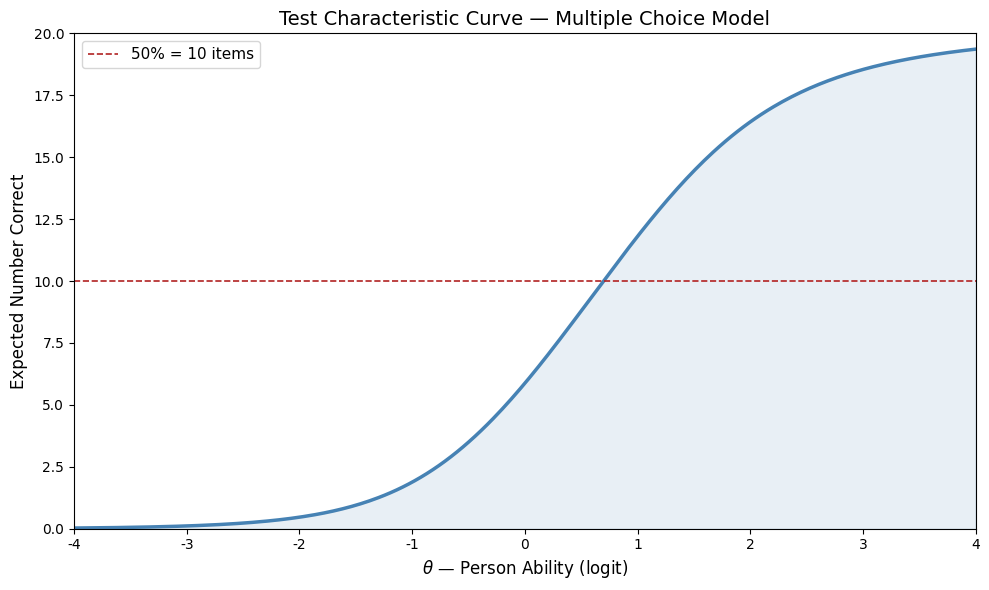

In [8]:
tcc = np.zeros(len(theta_range))
for i in range(I):
    for t_idx, t in enumerate(theta_range):
        pr = mcm_probs(t, a_key_est[i], d_key_est[i], a_foil_est[i], d_foil_est[i])
        tcc[t_idx] += pr[0]  # probability of key

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(theta_range, tcc, color='steelblue', linewidth=2.5)
ax.fill_between(theta_range, 0, tcc, alpha=0.12, color='steelblue')
ax.axhline(I / 2, color='firebrick', linestyle='--', linewidth=1.2, label=f'50% = {I//2} items')
ax.set_xlabel('$\\theta$ — Person Ability (logit)', fontsize=12)
ax.set_ylabel('Expected Number Correct', fontsize=12)
ax.set_title('Test Characteristic Curve — Multiple Choice Model', fontsize=14)
ax.set_xlim(-4, 4); ax.set_ylim(0, I); ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'tcc_mcm.png'), dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Posterior Parameter Density (Logit Scale) ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
fig.suptitle('MCM — Estimated Parameter Distributions', fontsize=13, fontweight='bold')

a_foil_flat  = a_foil_est.ravel()
d_foil_flat  = d_foil_est.ravel()

panels = [
    (axes[0], theta_est,   r'$\hat{\theta}_j$  (person ability)',     'steelblue',  'logit'),
    (axes[1], a_key_est,   r'$\hat{a}_{key}$  (key slope)',            'seagreen',   'untransformed'),
    (axes[2], d_key_est,   r'$\hat{d}_{key}$  (key intercept)',        'firebrick',  'logit'),
    (axes[3], d_foil_flat, r'$\hat{d}_{foil}$  (foil intercepts)',     'darkorange', 'logit'),
]

for ax, vals, title, color, unit in panels:
    ax.hist(vals, bins=max(8, len(vals)//3), density=True,
            color=color, alpha=0.35, edgecolor='white')
    if len(vals) >= 3:
        xs = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 300)
        kde = gaussian_kde(vals, bw_method='scott')
        ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={vals.mean():.2f}')
    ax.set_xlabel(f'Value  ({unit})', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{title}  (n={len(vals)})', fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'density_mcm.png'), dpi=120, bbox_inches='tight')
plt.show()
